In [1]:
import sys, os
sys.path.append("../")

import jax
jax.config.update("jax_enable_x64", True)

from qd_solve import *
from qd_solve.eig import *
from qd_solve.operator import *
from qd_solve.split import *
from qd_solve.system import *
from qd_solve.timestepper import *
from qd_solve.spaces.pseudospectral import *
from qd_solve.spaces.finite_difference import *
from qd_solve.exp import *

from miscutils.plot import animate

import jax.numpy as jnp
import diffrax

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import Image

In [2]:
mass = 1.0
hbar = 1.0
potential = lambda x: 0.5 * x ** 2

V = FiniteDifferencePotentialEnergy(potential)
L = FiniteDifferenceLaplacian()

In [3]:
x0 = -10
xf = 10
num_steps = 1000
num_modes = 250

space = FiniteDifference(x0, xf, num_steps)
#y_vals = jnp.ones_like(mesh.x_range)
y_vals = jnp.exp(-0.5 * (space.x_range - 5) ** 2)
y = space.from_values(y_vals)

In [7]:
c1 = lambda t: jnp.exp(-0.5 * t)
c2 = lambda t: jnp.exp(0.5 * t)

#H = lambda t: c1(t) * T + c2(t) * V

t0 = 0.0
t1 = 4 * jnp.pi
dt = 0.01

#L = L.set_exponentiator(ScaleSquareExponentiator(L, space, dt))
H1 = (V - 0.5 * L).set_exponentiator(Strang())
sys1 = TimeInvariantSystem(H1)
%time ys, t_range = sys1.propagate(t0, t1, dt, y, Midpoint())

#H2 = (V - 0.5 * L).set_exponentiator(Yoshida(1))
#sys2 = TimeInvariantSystem(H2)
#%time ys2, t_range = sys2.propagate(t0, t1, dt, y, Midpoint())

#jnp.linalg.norm(ys2[-1].coeffs - ys1[-1].coeffs)

/home/ahmed/Documents/UCI/research/quantum_dynamics/notebooks/../qd_solve/exp.py:214: UserWarning: Exponentiator is acting on the operator:
FiniteDifferenceLaplacian(
  exponentiator=ScaleSquareExponentiator(
    m=50,
    s=6,
    mu=f64[],
    op=FiniteDifferenceLaplacian(
      exponentiator=ScaleSquareExponentiator(
        m=50,
        s=3,
        mu=f64[],
        op=ScalarMulOperator(
          op=FiniteDifferenceLaplacian(exponentiator=CrankNicolson()), c=-0.5
        )
      )
    )
  )
)
which different from the one it was constructed with:
FiniteDifferenceLaplacian(
  exponentiator=ScaleSquareExponentiator(
    m=50,
    s=3,
    mu=f64[],
    op=ScalarMulOperator(
      op=FiniteDifferenceLaplacian(exponentiator=CrankNicolson()), c=-0.5
    )
  )
)
This may cause accuracy and reliability issues
  warnings.warn(


CPU times: user 3.02 s, sys: 1.15 s, total: 4.17 s
Wall time: 4.24 s


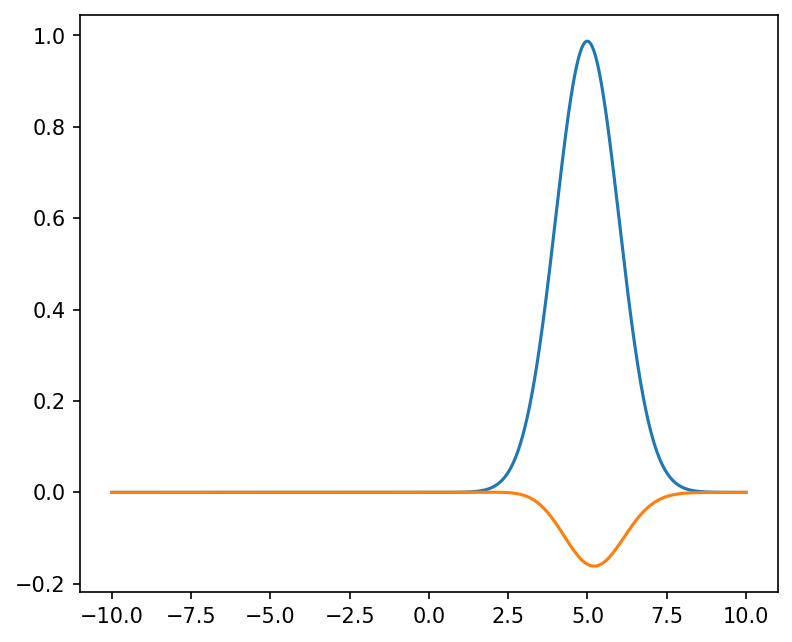

In [8]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

ax.plot(space.x_range, jnp.real(ys[-1].values))
ax.plot(space.x_range, jnp.imag(ys[-1].values))

#ax.plot(space.x_range, jnp.real(ys1[-1].values))
#ax.plot(space.x_range, jnp.imag(ys1[-1].values))

#ax.plot(space.x_range, jnp.real(ys2[-1].values))
#ax.plot(space.x_range, jnp.imag(ys2[-1].values))

plt.show()
plt.close(fig)

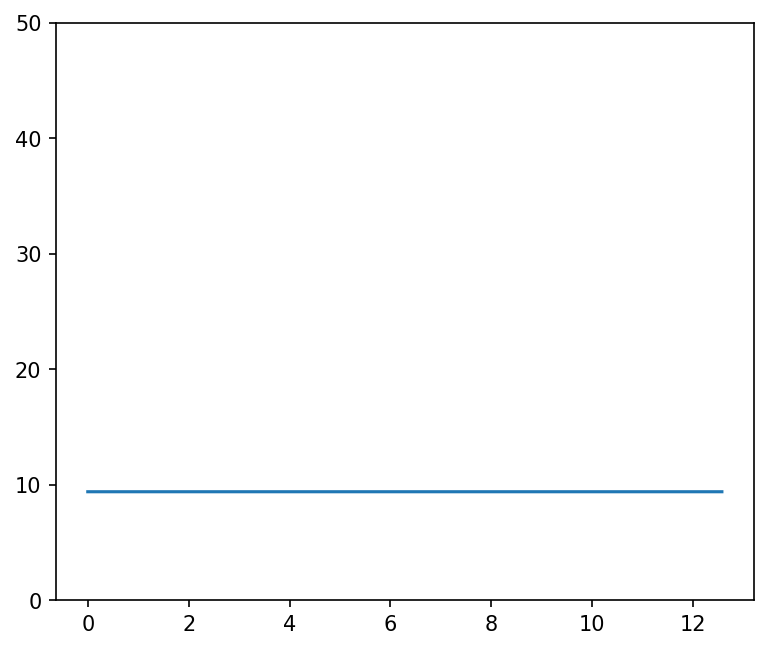

In [9]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

#jnp.linalg.norm(ys.values, axis=1)

ax.plot(t_range, jnp.linalg.norm(ys.values, axis=1))

ax.set_ylim([0, 50])

plt.show()
plt.close(fig)

In [10]:
n = 2
num_frames =100

def func(idx, ax, state, args):
    y_vals = ys[-n * idx].values
    ax.plot(space.x_range, jnp.real(y_vals))
    ax.plot(space.x_range, jnp.imag(y_vals))

    #y_vals = ys2[-n * idx].values
    #ax.plot(space.x_range, jnp.real(y_vals))
    #ax.plot(space.x_range, jnp.imag(y_vals))
    #ax.plot(space.x_range, jnp.abs(y_vals))

    ax.set_xlim([-12, 12])
    ax.set_ylim([-2.0, 2.0])

animate(func, t_range.shape[0] // 2, filename="output.gif")
Image(url="output.gif")  